In [1045]:
#import tidy all data csv file
import os
import pandas as pd
import numpy as np

tidy_all_data = pd.read_csv(os.path.join('..','..','data','processed','tidy_all_metrics.csv'))



In [1046]:
tidy_all_data[tidy_all_data['Year']==2007].tail()

,Municipality_Name,Year,Metric,Value,Unit
127932,Warfield,2007,Log_Transportation_Total_Emissions_Factor,0.000153,Log_CO2_per_km_travelled
127933,West Vancouver,2007,Log_Transportation_Total_Emissions_Factor,0.000146,Log_CO2_per_km_travelled
127934,Whistler,2007,Log_Transportation_Total_Emissions_Factor,0.000167,Log_CO2_per_km_travelled
127935,White Rock,2007,Log_Transportation_Total_Emissions_Factor,0.000147,Log_CO2_per_km_travelled
127936,Williams Lake,2007,Log_Transportation_Total_Emissions_Factor,0.000212,Log_CO2_per_km_travelled


In [1047]:
# choose reference year and metric list (edit to taste)
REFERENCE_YEAR = 2021


decomposition_analysis_features = [
]

decoupling_analysis_features = [
]

share_change_analysis_features = [
]

just_transition_analysis_features = [
    
] #what's great of including this here is that looking at whether labour force and education decreased in an area while 
# emissions decreased goes against the justice framework. We want labour force, education, and wellbeing in general to stay good while we reduce emissions!!!


all_key_features = [
    # Context
    'Remoteness',
    'Latitude',
    'Longitude',
    
    #Climate action
    'Climate_Action_N_Barriers',
    'Climate_Action_Score',
    
    # Socio-economic baseline
    'Log_Population',
    'Income', 'Education', 'Housing', 'Labour_Force', #'CWB',
    
    # Socio-economic trajectories
    'Income_Percent_Change', 'Education_Percent_Change', 
    'Housing_Percent_Change', 'Labour_Percent_Change', 
    'Log_Population_Change_2006_2021',
    
    # Low-emissions energy shares baseline
    'Utility_Residential_Electricity_Energy_Share',
    'Utility_CSMI_Electricity_Energy_Share',
    'Transportation_Low_Emission_Vehicle_km_Travelled_Share',
    
    # Economic structure baseline
    'Utility_CSMI_Total_Energy_Share', #this is share on total utility energy, not including tranport

    # Energy transition trajectories
    'Residential_Electricity_Share_Percent_Change',
    'CSMI_Electricity_Share_Percent_Change',
    'Transport_Low_Emission_Share_Percent_Change',
    
    # Economic transition trajectories
    'CSMI_Total_Energy_Share_Percent_Change',
    
    # Per capita values for 2021
    'Log_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita',
    'Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita',
    'Log_Residential_Electricity_Per_Capita',
    'Log_Residential_Polluting_Per_Capita',
    'Log_CSMI_Electricity_Per_Capita' ,
    'Log_CSMI_Polluting_Per_Capita' ,

    # Per capita changes 2007-2021 (pop from 2006 as a proxy for 2007)
    'Log_Diff_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita',
    'Log_Diff_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita',
    'Log_Diff_Residential_Electricity_Per_Capita',
    'Log_Diff_Residential_Polluting_Per_Capita',
    'Log_Diff_CSMI_Electricity_Per_Capita',
    'Log_Diff_CSMI_Polluting_Per_Capita',
    
    # Emission factor end year levels
    #'Log_Utility_Residential_Electricity_Emissions_Factor', #-> everyone has the same emissions factor because everyone is connected to the same grid
    'Log_Utility_Residential_Polluting_Emissions_Factor',
    #'Log_Utility_CSMI_Electricity_Emissions_Factor', #-> everyone has the same emissions factor because everyone is connected to the same grid
    #'Log_Utility_CSMI_Polluting_Emissions_Factor', #-> not estimated due to zero divided by zero
    'Log_Transport_Low_Emission_Emissions_Factor',
    'Log_Transport_Polluting_Emissions_Factor',
    
    # Emission factor changes 2007-2021
    #'Log_Diff_Utility_Residential_Electricity_Emissions_Factor', #-> everyone has the same difference because everyone is connected to the same grid 
    'Log_Diff_Utility_Residential_Polluting_Emissions_Factor',
    #'Log_Diff_Utility_CSMI_Electricity_Emissions_Factor', -> #everyone has the same difference because everyone is connected to the same grid
    #'Log_Diff_Utility_CSMI_Polluting_Emissions_Factor', -> not estimated due to zero divided by zero
    'Log_Diff_Transport_Low_Emission_Emissions_Factor',
    'Log_Diff_Transport_Polluting_Emissions_Factor'
]

low_emission_transport_policy = [
    'Latitude', #proxy for different temperatures north/south. Really cold regions suffer from lower battery performance
    'Remoteness', #more remote communities may need to travel further distances and have more range anxiety with EVs (but hybrids have better milage though)
    'Income', # income affects the ability to purchase EVs or hybrids since their upfront cost can be higher
    'Housing', # housing quality and quantity affects one's ability to charge their EV (apartments have more difficulty installing chargers, and housing needing maintenance may not have proper infrastructure to install chargers either)
    'Labour_Force', #labour force affects ability to do renovations to install EV chargers and to maintain EVs 
    'Education', #education may affect ability to install EV chargers
    'Log_Population', #population levels affect demand for EVs and the likelihood of having people who can maintain the infrastructure for EVs (e.g. mechanics who can fix them, people who can install chargers, etc.)
    
     # Socio-economic trajectories
    'Income_Percent_Change', 'Education_Percent_Change', 
    'Housing_Percent_Change', 'Labour_Percent_Change', 
    'Log_Population_Change_2006_2021',

    #Climate action institutional capacity
    'Climate_Action_N_Barriers',
    'Climate_Action_Score',
    
    'Log_Transportation_Total_Vehicle_km_Travelled_Per_Capita',
    'Log_Transportation_Total_Emissions_Factor',
    'Log_Diff_Transportation_Total_Vehicle_km_Travelled_Per_Capita',
    'Log_Diff_Transportation_Total_Emissions_Factor',

    'Log_Residential_Electricity_Per_Capita', # home electrification level important as people often charge EVs at home
    ]

residential_electrification_policy = [
    'Latitude', #proxy for different temperatures north/south
    'Income', #income affects ability to purchase heatpumps
    'Housing', #housing quality and availability affects ability to install heatpumps
    'Education', #education may affect ability to navigate installing heatpumps and also signal more progressive communities that are more likely to adopt heatpumps
    'Labour_Force', #labour force affects ability to do renovations to install heatpumps 
    'Log_Population',  
    'Remoteness',  
    
    # Socio-economic trajectories
    'Income_Percent_Change', 'Education_Percent_Change', 
    'Housing_Percent_Change', 'Labour_Percent_Change', 
    'Log_Population_Change_2006_2021',
    
    #Climate action institutional capacity
    'Climate_Action_N_Barriers',
    'Climate_Action_Score',
    
    # Aggregate per capita energy and emissions
    'Log_Utility_Residential_Emissions_Factor', 
    'Log_Residential_Total_Energy_Per_Capita', 
    'Log_Diff_Utility_Residential_Emissions_Factor',
    'Log_Diff_Residential_Total_Energy_Per_Capita',
]

sensitivity_test_features = [
    #'Latitude', #proxy for different temperatures north/south
    'Income', #income affects ability to purchase heatpumps
    'Housing', #housing quality and availability affects ability to install heatpumps
    #'Education', #education may affect ability to navigate installing heatpumps and also signal more progressive communities that are more likely to adopt heatpumps
    #'Labour_Force', #labour force affects ability to do renovations to install heatpumps 
    #'Log_Population',  
    #'Remoteness',  
    
    # Socio-economic trajectories
    #'Income_Percent_Change', 'Education_Percent_Change', 
    #'Housing_Percent_Change', 'Labour_Percent_Change', 
    #'Log_Population_Change_2006_2021',
    
    # Climate action
    #'Climate_Action_N_Barriers',
    #'Climate_Action_Score',
    
    #'Log_Residential_Electricity_Per_Capita', # Electricity use at homes important as heatpumps are electric
    #'Log_Residential_Polluting_Per_Capita', # Polluting energy use at homes important to signal places needing to transition
    #'Log_Diff_Residential_Electricity_Per_Capita', # Electricity changes at homes important as heatpumps are electric
    #'Log_Diff_Residential_Polluting_Per_Capita',  # Polluting energy changes use at homes important to signal places already transitioning or starting to use even more polluting energy
    
    # Aggregate per capita energy and emissions
    'Log_Utility_Residential_Emissions_Factor', 
    'Log_Residential_Total_Energy_Per_Capita', 
    #'Log_Diff_Utility_Residential_Emissions_Factor',
    #'Log_Diff_Residential_Total_Energy_Per_Capita',
]
    

top_features_residential_electrification_policy = [
    #top 9 features ranked by eta-squared when clustering using 18 features and averaging eta-squared for different cluster numbers
    'Latitude', 
    'Education', 
    'Log_Population',
    'Remoteness',
        
    'Log_Population_Change_2006_2021',
    
    'Climate_Action_Score',
    
    'Log_Utility_Residential_Emissions_Factor', 
    'Log_Residential_Total_Energy_Per_Capita', 
    'Log_Diff_Utility_Residential_Emissions_Factor',
]


industrial_policy_features = [
    # Socio-economic baseline
    'Log_Population',
    'Income', 'Education', 'Housing', 'Labour_Force',
    
    # Socio-economic trajectories
    'Income_Percent_Change', 'Education_Percent_Change', 
    'Housing_Percent_Change', 'Labour_Percent_Change', 
    'Log_Population_Change_2006_2021',
        
    'Log_Diff_CSMI_Electricity_Per_Capita',
    'Log_Diff_CSMI_Polluting_Per_Capita',
    'Log_CSMI_Electricity_Per_Capita' ,
    'Log_CSMI_Polluting_Per_Capita',
    
    #if we want to use the aggregate per capita energy
    'Log_CSMI_Total_Energy_Per_Capita',
    'Log_Diff_CSMI_Total_Energy_Per_Capita',
    'Log_Utility_CSMI_Emissions_Factor',
    'Log_Diff_Utility_CSMI_Emissions_Factor'
]



socio_economic_political_context = [
    #Climate action
    'Climate_Action_N_Barriers',
    'Climate_Action_Score',
    
    # Socio-economic baseline
    'Log_Population',
    'Income', 'Education', 'Housing', 'Labour_Force', #'CWB',
    
    # Socio-economic trajectories
    'Income_Percent_Change', 'Education_Percent_Change', 
    'Housing_Percent_Change', 'Labour_Percent_Change', 
    'Log_Population_Change_2006_2021',
]


wellbeing_features = [
    # Wellbeing baseline
    'Income', 'Education', 'Housing', 'Labour_Force', #'CWB',
    
    # Wellbeing trajectories
    'income_percent_change', 'education_percent_change', 
    'housing_percent_change', 'labour_percent_change', 
    'population_percent_change'
    ]

climate_action_summary_features = [
     #Climate action
    'Climate_Action_N_Barriers',
    'Climate_Action_Score'
    ]

#variables that won't change over time (remoteness could change over decades or centuries or with a large intervention, but lat,lon won't change)
structural = [
    'Remoteness', 
    'Latitude', 
    'Longitude',
    ]

features_visual_inspection =[
    'Remoteness',
    'Latitude',
    'Utility_Residential_Electricity_Energy_Share',
    'Log_CSMI_Polluting_Per_Capita',
]

features_to_use = low_emission_transport_policy
#sensitivity_test_features
#top_features_residential_electrification_policy
#residential_electrification_policy
# low_emission_transport_policy


# build wide feature matrix for REFERENCE_YEAR
df_base_year = tidy_all_data.loc[tidy_all_data['Year'] == REFERENCE_YEAR, ['Municipality_Name','Metric','Value']].copy()
# Find duplicates
duplicates = df_base_year[df_base_year.duplicated(subset=['Municipality_Name', 'Metric'], keep=False)]
print(f"Found {len(duplicates)} duplicate rows:")
display(duplicates.sort_values(['Municipality_Name', 'Metric']))

df_wide_base_year = df_base_year.pivot(index='Municipality_Name', columns='Metric', values='Value')
# ensure chosen features are present, add missing as NaN
for f in features_to_use:
    if f not in df_wide_base_year.columns:
        df_wide_base_year[f] = np.nan

# select only desired columns and drop rows with no data at all
X = df_wide_base_year[features_to_use].copy()

# diagnostic: find missing values BEFORE scaling/PCA (PCA/Scaler do not accept NaN)
nan_counts = X.isna().sum()
if nan_counts.sum() > 0:
    print("Missing values present. Counts per feature:\n", nan_counts[nan_counts > 0])
    nan_rows = X[X.isna().any(axis=1)]
    print("\nCommunities with missing data (total {}):".format(len(nan_rows)))
    for idx, row in nan_rows.iterrows():
        missing_feats = row[row.isna()].index.tolist()
        print(f" - {idx}: missing {missing_feats}")
    # show some raw tidy rows for the first few affected communities to investigate source
    sample_comm = list(nan_rows.index)[:8]
    print("\nSample raw tidy_all_data rows for inspection:")
    display(tidy_all_data[tidy_all_data['Municipality_Name'].isin(sample_comm)].sort_values(['Municipality_Name','Year','Metric']).tail(100))
else:
    print("No missing values found in X.")


Found 0 duplicate rows:


,Municipality_Name,Metric,Value


No missing values found in X.


In [1048]:
df_base_year.head()

,Municipality_Name,Metric,Value
22,Abbotsford,Utility_Residential_Polluting_Energy,2.814366e+06
23,Abbotsford,Utility_CSMI_Polluting_Energy,5.634019e+06
46,Alert Bay,Utility_Residential_Polluting_Energy,5.090462e+03
47,Alert Bay,Utility_CSMI_Polluting_Energy,0.000000e+00
70,Anmore,Utility_Residential_Polluting_Energy,1.072483e+05


In [1049]:
df_base_year[df_base_year['Metric'] == 'Log_Utility_Residential_Emissions_Factor']

,Municipality_Name,Metric,Value
126320,Abbotsford,Log_Utility_Residential_Emissions_Factor,0.013136
126321,Alert Bay,Log_Utility_Residential_Emissions_Factor,0.006684
126322,Anmore,Log_Utility_Residential_Emissions_Factor,0.014853
126323,Armstrong,Log_Utility_Residential_Emissions_Factor,0.014273
126324,Ashcroft,Log_Utility_Residential_Emissions_Factor,0.014270
...,...,...,...
126462,Warfield,Log_Utility_Residential_Emissions_Factor,0.015476
126463,West Vancouver,Log_Utility_Residential_Emissions_Factor,0.015301
126464,Whistler,Log_Utility_Residential_Emissions_Factor,0.008204
126465,White Rock,Log_Utility_Residential_Emissions_Factor,0.012365


In [1050]:
# clustering municipalities based on PCA of selected metrics

# --- PCA + clustering pipeline (add / run in a new cell) ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

standardize = True
#select which X to use for clustering (scaled or original)
if standardize:
    # Standardize (use X for the pipeline)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_for_clustering = X_scaled.copy()
    # PCA: keep components that explain 80% variance for clustering, but compute 2D for plotting
    pca80 = PCA(n_components=0.80, svd_solver='full')
    X_pca_80 = pca80.fit_transform(X_for_clustering)
    print(f"PCA reduced to {X_pca_80.shape[1]} components to explain 80% variance")
else: 
    X_for_clustering = X.copy()
    # PCA: keep components that explain 80% variance for clustering, but compute 2D for plotting
    pca80 = PCA(n_components=0.80, svd_solver='full')
    X_pca_80 = pca80.fit_transform(X_for_clustering)

    print(f"PCA reduced to {X_pca_80.shape[1]} components to explain 80% variance")


PCA reduced to 8 components to explain 80% variance


In [1051]:

from diptest import diptest

multimodal_features = []
for col in X.columns:
    dip, p = diptest(X[col].values)
    if p < 0.1:
        multimodal_features.append(col)
        print(f"{col}: p={p:.4f} (non-normal)")
        


Remoteness: p=0.0002 (non-normal)
Income: p=0.0065 (non-normal)
Housing: p=0.0000 (non-normal)
Labour_Force: p=0.0001 (non-normal)
Education: p=0.0659 (non-normal)
Housing_Percent_Change: p=0.0000 (non-normal)
Labour_Percent_Change: p=0.0000 (non-normal)
Climate_Action_N_Barriers: p=0.0000 (non-normal)
Climate_Action_Score: p=0.0000 (non-normal)


In [1052]:
multimodal_features = []
num_features = X_scaled.shape[1]
for i in range (1, num_features):
    dip, p = diptest(X_scaled[:,i])
    if p < 0.1:
        multimodal_features.append(col)
        print(f"{col}: p={p:.4f} (non-normal)")

Log_Residential_Electricity_Per_Capita: p=0.0002 (non-normal)
Log_Residential_Electricity_Per_Capita: p=0.0065 (non-normal)
Log_Residential_Electricity_Per_Capita: p=0.0000 (non-normal)
Log_Residential_Electricity_Per_Capita: p=0.0001 (non-normal)
Log_Residential_Electricity_Per_Capita: p=0.0659 (non-normal)
Log_Residential_Electricity_Per_Capita: p=0.0000 (non-normal)
Log_Residential_Electricity_Per_Capita: p=0.0000 (non-normal)
Log_Residential_Electricity_Per_Capita: p=0.0000 (non-normal)
Log_Residential_Electricity_Per_Capita: p=0.0000 (non-normal)


In [1053]:

# Correlation matrix
corr_matrix = X.corr()#.abs()

# Find pairs with correlation > 0.7
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.8 or corr_matrix.iloc[i, j] < -0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Highly correlated pairs (keep one, drop other):")
for v1, v2, corr in high_corr_pairs:
    print(f"  {v1} <-> {v2}: {corr:.2f}")
    


Highly correlated pairs (keep one, drop other):
  Log_Transportation_Total_Emissions_Factor <-> Log_Diff_Transportation_Total_Emissions_Factor: -0.92


In [1054]:
from sklearn.cluster import KMeans
import numpy as np

def gap_statistic(X, k_range=range(1, 10), n_refs=10):
    gaps = []
    for k in k_range:
        # Your data's within-cluster dispersion
        if k == 1:
            Wk = np.sum((X - X.mean(axis=0))**2)
        else:
            km = KMeans(n_clusters=k, random_state=42)
            km.fit(X)
            Wk = km.inertia_
        
        # Reference (random uniform) dispersion
        ref_disps = []
        for _ in range(n_refs):
            X_random = np.random.uniform(X.min(axis=0), X.max(axis=0), X.shape)
            if k == 1:
                ref_disps.append(np.sum((X_random - X_random.mean(axis=0))**2))
            else:
                km_ref = KMeans(n_clusters=k, random_state=42)
                km_ref.fit(X_random)
                ref_disps.append(km_ref.inertia_)
        
        gap = np.mean(np.log(ref_disps)) - np.log(Wk)
        gaps.append(gap)
    
    return list(k_range), gaps

ks, gaps = gap_statistic(X_pca_80)
print("If gap peaks at k=1 or stays flat, no clustering may be justified.")
for k, gap in zip(ks, gaps):
    print(f"k={k}: gap={gap:.3f}")

If gap peaks at k=1 or stays flat, no clustering may be justified.
k=1: gap=0.849
k=2: gap=0.994
k=3: gap=0.986
k=4: gap=1.037
k=5: gap=1.026
k=6: gap=1.075
k=7: gap=1.104
k=8: gap=1.069
k=9: gap=1.038


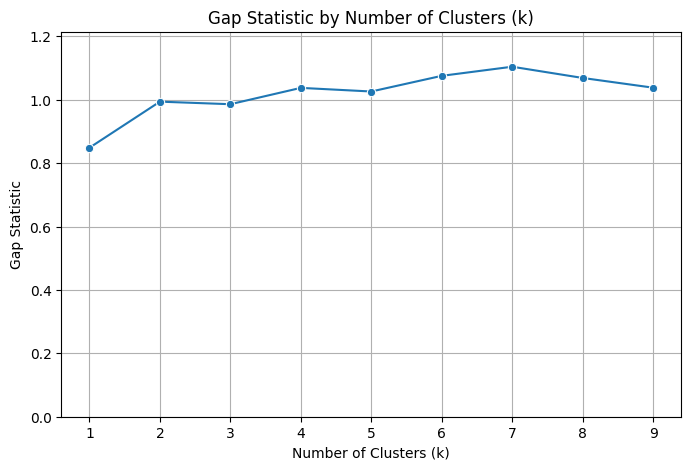

In [1055]:
#plot gap score vs k
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.lineplot(x=ks, y=gaps, marker='o')
plt.title('Gap Statistic by Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Gap Statistic')
plt.ylim(0.0, max(gaps)*1.1)
plt.xticks(ks)
plt.grid()
plt.show()

In [1056]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mstats

# choose number of clusters with silhouette (k=2..8)
best_k, best_score = None, -1
scores = {}
all_labels = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = km.fit_predict(X_pca_80) #(X_for_clustering)
    all_labels[k] = labels
    score = silhouette_score(X_pca_80, labels) #(X_for_clustering, labels)
    scores[k] = score
    if score > best_score:
        best_score = score
        best_k = k
print("Best k:", best_k, "score:", best_score)
print("Silhouette scores by k:", scores)

"""
manual_k = 7
# Fit final KMeans on PCA space
kmeans_final = KMeans(n_clusters=manual_k, random_state=42, n_init=100)
labels_final = kmeans_final.fit_predict(X_pca_80) #(X_for_clustering)

# assemble results dataframe and save
clusters_df = pd.DataFrame({
    'Municipality_Name': X.index,
    'Cluster': labels_final
}).set_index('Municipality_Name')

# merge back some original features for inspection
clustered = X.merge(clusters_df, left_index=True, right_index=True)

# save CSV
clustered.reset_index().to_csv(os.path.join('..','..','data','processed','municipality_clusters_baseline2021.csv'), index=False)
"""

Best k: 2 score: 0.2737450060116638
Silhouette scores by k: {2: np.float64(0.2737450060116638), 3: np.float64(0.15312557619444483), 4: np.float64(0.17280296233740303), 5: np.float64(0.17397316032620946), 6: np.float64(0.18767369842389203), 7: np.float64(0.1568123322691919), 8: np.float64(0.15799413797580855), 9: np.float64(0.16246514872425882)}


"\nmanual_k = 7\n# Fit final KMeans on PCA space\nkmeans_final = KMeans(n_clusters=manual_k, random_state=42, n_init=100)\nlabels_final = kmeans_final.fit_predict(X_pca_80) #(X_for_clustering)\n\n# assemble results dataframe and save\nclusters_df = pd.DataFrame({\n    'Municipality_Name': X.index,\n    'Cluster': labels_final\n}).set_index('Municipality_Name')\n\n# merge back some original features for inspection\nclustered = X.merge(clusters_df, left_index=True, right_index=True)\n\n# save CSV\nclustered.reset_index().to_csv(os.path.join('..','..','data','processed','municipality_clusters_baseline2021.csv'), index=False)\n"

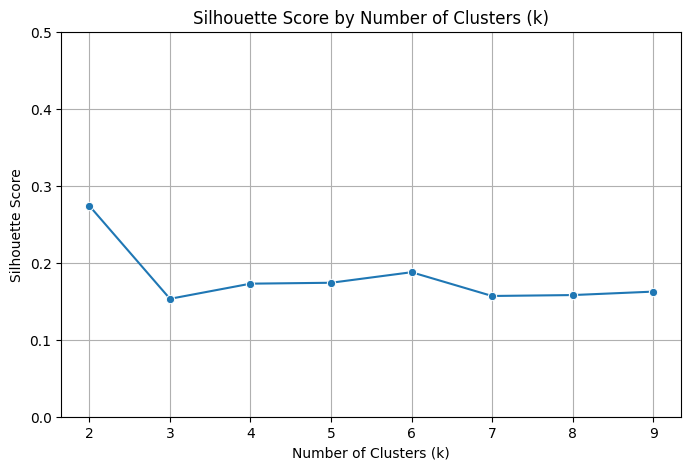

In [1057]:
#plot silhouette score vs k
plt.figure(figsize=(8,5))
sns.lineplot(x=list(scores.keys()), y=list(scores.values()), marker='o')
plt.title('Silhouette Score by Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
#make y axis start at 0.0 and end at 0.5
plt.ylim(0.0, 0.5)
plt.xticks(list(scores.keys()))
plt.grid()
plt.show()


In [1058]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mstats

manual_k = 7
# Fit final KMeans on PCA space
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=100)
labels_final = kmeans_final.fit_predict(X_pca_80)
labels_final = labels_final + 1  # Make cluster labels start from 1 instead of 0

# assemble results dataframe and save
clusters_df = pd.DataFrame({
    'Municipality_Name': X.index,
    'Cluster': labels_final
}).set_index('Municipality_Name')

# merge back some original features for inspection
clustered = X.merge(clusters_df, left_index=True, right_index=True)

# save CSV
clustered.reset_index().to_csv(os.path.join('..','..','data','processed','municipality_clusters_baseline2021.csv'), index=False)

In [1059]:
clustered#['Latitude']

,Latitude,Remoteness,Income,Housing,Labour_Force,Education,Log_Population,Income_Percent_Change,Education_Percent_Change,Housing_Percent_Change,Labour_Percent_Change,Log_Population_Change_2006_2021,Climate_Action_N_Barriers,Climate_Action_Score,Log_Transportation_Total_Vehicle_km_Travelled_Per_Capita,Log_Transportation_Total_Emissions_Factor,Log_Diff_Transportation_Total_Vehicle_km_Travelled_Per_Capita,Log_Diff_Transportation_Total_Emissions_Factor,Log_Residential_Electricity_Per_Capita,Cluster
Municipality_Name,,,,,,,,,,,,,,,,,,,,
Abbotsford,49.052222,0.137854,77.0,93.0,87.0,63.0,5.186176,10.000000,10.526316,-2.105263,-2.247191,0.093231,3.0,2.0,4.019773,0.000164,0.071227,3.372551,1.139457,2
Alert Bay,50.583889,0.532555,75.0,87.0,80.0,68.0,2.652246,5.633803,25.925926,-3.333333,-13.043478,-0.092828,4.0,1.0,3.823133,0.000140,0.143130,3.415681,1.486558,1
Anmore,49.314444,0.105959,94.0,96.0,85.0,77.0,3.372175,8.045977,6.944444,-1.030928,-8.602151,0.120537,4.0,0.0,3.890847,0.000134,-0.066367,3.442974,1.360243,2
Armstrong,50.448333,0.282934,78.0,97.0,88.0,62.0,3.726156,13.043478,14.814815,0.000000,2.325581,0.098688,4.0,0.0,4.045750,0.000163,-0.033148,3.366568,1.201166,2
Ashcroft,50.721389,0.404410,78.0,90.0,81.0,56.0,3.222716,8.333333,12.000000,-1.098901,0.000000,0.001563,4.0,2.0,4.059918,0.000170,0.042582,3.362708,1.242716,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Warfield,49.094167,0.382688,82.0,93.0,87.0,70.0,3.243782,12.328767,9.375000,-4.123711,-1.136364,0.005987,5.0,1.0,4.003123,0.000144,0.052737,3.453320,1.131529,2
West Vancouver,49.331111,0.063003,100.0,95.0,81.0,83.0,4.644655,1.010101,5.063291,-1.041667,-5.813953,0.020053,3.0,5.0,3.808674,0.000127,-0.146418,3.473699,1.323525,2
Whistler,50.117222,0.199452,87.0,94.0,86.0,79.0,4.145569,7.407407,5.333333,-2.083333,-7.526882,0.179521,3.0,4.0,3.963971,0.000144,-0.077418,3.415571,1.729049,2


In [1060]:
x=X_pca_80[:,0]
y=X_pca_80[:,1]
dip, p = diptest(X_pca_80[:,0])
print(f"diptest for PCA1 p={p:.4f}")
dip, p = diptest(X_pca_80[:,1])
print(f"diptest for PCA2 p={p:.4f}")
dip, p = diptest(X_pca_80[:,2])
print(f"PCA3 p={p:.4f}")
dip, p = diptest(X_for_clustering[:,1])
print(f"diptest for original p={p:.4f}")

diptest for PCA1 p=0.3882
diptest for PCA2 p=0.9835
PCA3 p=0.9172
diptest for original p=0.0002


In [1061]:
# Quick diagnostics: which input variables drive PCs and clusters
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from IPython.display import display

# PCA loadings (full PCA on standardized inputs)
pca_full = PCA().fit(X_for_clustering)
loadings = pd.DataFrame(pca_full.components_.T,
                        index=X.columns,
                        columns=[f'PC{i+1}' for i in range(pca_full.components_.shape[0])])
explained = pd.Series(pca_full.explained_variance_ratio_, index=loadings.columns)

# Find variables with max absolute loading < 0.2 across PC1-PC4
max_loadings = loadings.iloc[:, :4].abs().max(axis=1)
low_contributors = max_loadings[max_loadings < 0.2].index.tolist()
print("Consider removing:", low_contributors)

print("Explained variance (first 6 PCs):")
print(explained.head(6).round(3))

print("\nTop contributors to PC1 (absolute loading):")
display(loadings['PC1'].abs().sort_values(ascending=False).head(10))

print("\nTop contributors to PC2 (absolute loading):")
display(loadings['PC2'].abs().sort_values(ascending=False).head(10))

print("\nTop contributors to PC3 (absolute loading):")
display(loadings['PC3'].abs().sort_values(ascending=False).head(10))


Consider removing: []
Explained variance (first 6 PCs):
PC1    0.333
PC2    0.103
PC3    0.087
PC4    0.075
PC5    0.068
PC6    0.057
dtype: float64

Top contributors to PC1 (absolute loading):


Metric
Remoteness                                                  0.338504
Education                                                   0.335828
Log_Transportation_Total_Emissions_Factor                   0.335392
Log_Diff_Transportation_Total_Emissions_Factor              0.299304
Log_Population                                              0.297598
Latitude                                                    0.279139
Climate_Action_Score                                        0.272604
Log_Population_Change_2006_2021                             0.248470
Log_Transportation_Total_Vehicle_km_Travelled_Per_Capita    0.236672
Income                                                      0.220687
Name: PC1, dtype: float64


Top contributors to PC2 (absolute loading):


Metric
Income_Percent_Change                                            0.419173
Education_Percent_Change                                         0.360975
Labour_Percent_Change                                            0.345310
Log_Residential_Electricity_Per_Capita                           0.334209
Log_Transportation_Total_Vehicle_km_Travelled_Per_Capita         0.239153
Labour_Force                                                     0.219363
Income                                                           0.218087
Log_Diff_Transportation_Total_Emissions_Factor                   0.212125
Log_Population                                                   0.203229
Log_Diff_Transportation_Total_Vehicle_km_Travelled_Per_Capita    0.199853
Name: PC2, dtype: float64


Top contributors to PC3 (absolute loading):


Metric
Housing_Percent_Change                            0.420210
Latitude                                          0.401088
Climate_Action_N_Barriers                         0.330333
Log_Diff_Transportation_Total_Emissions_Factor    0.313050
Education_Percent_Change                          0.279160
Log_Population                                    0.275035
Log_Residential_Electricity_Per_Capita            0.270004
Log_Transportation_Total_Emissions_Factor         0.230686
Housing                                           0.207635
Labour_Force                                      0.200375
Name: PC3, dtype: float64

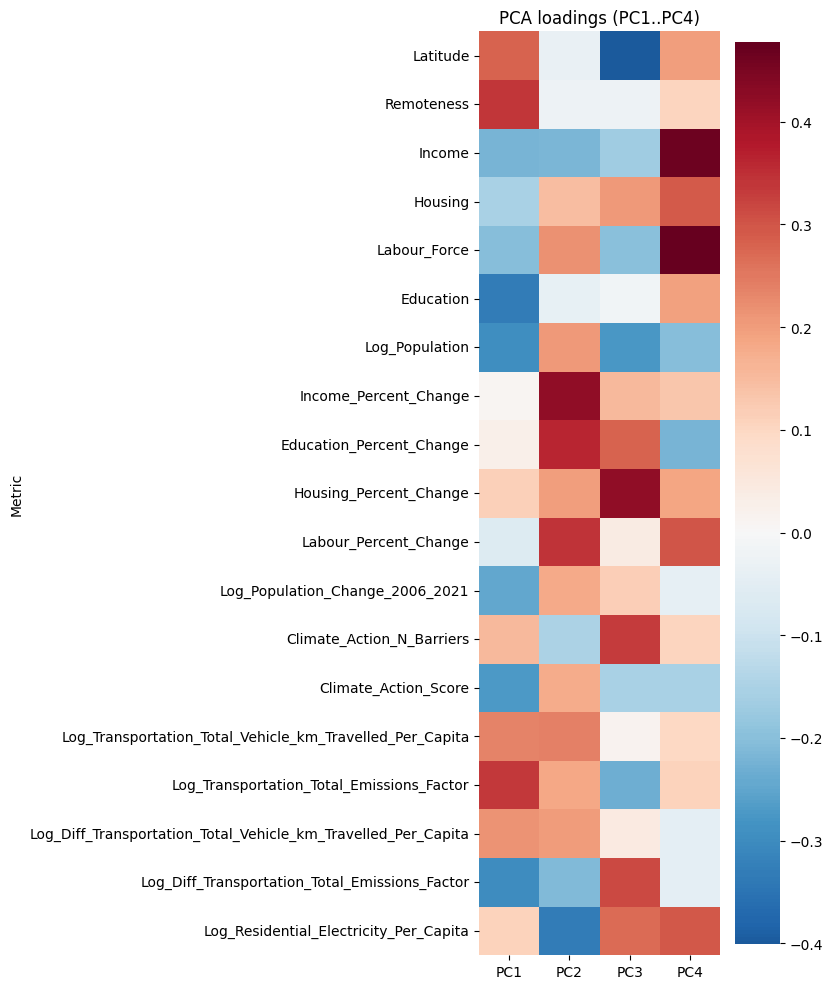

In [1062]:
# Heatmap of loadings for first 4 PCs
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,10))
sns.heatmap(loadings.iloc[:, :4], cmap='RdBu_r', center=0, annot=False)
plt.title('PCA loadings (PC1..PC4)')
plt.tight_layout()
plt.show()

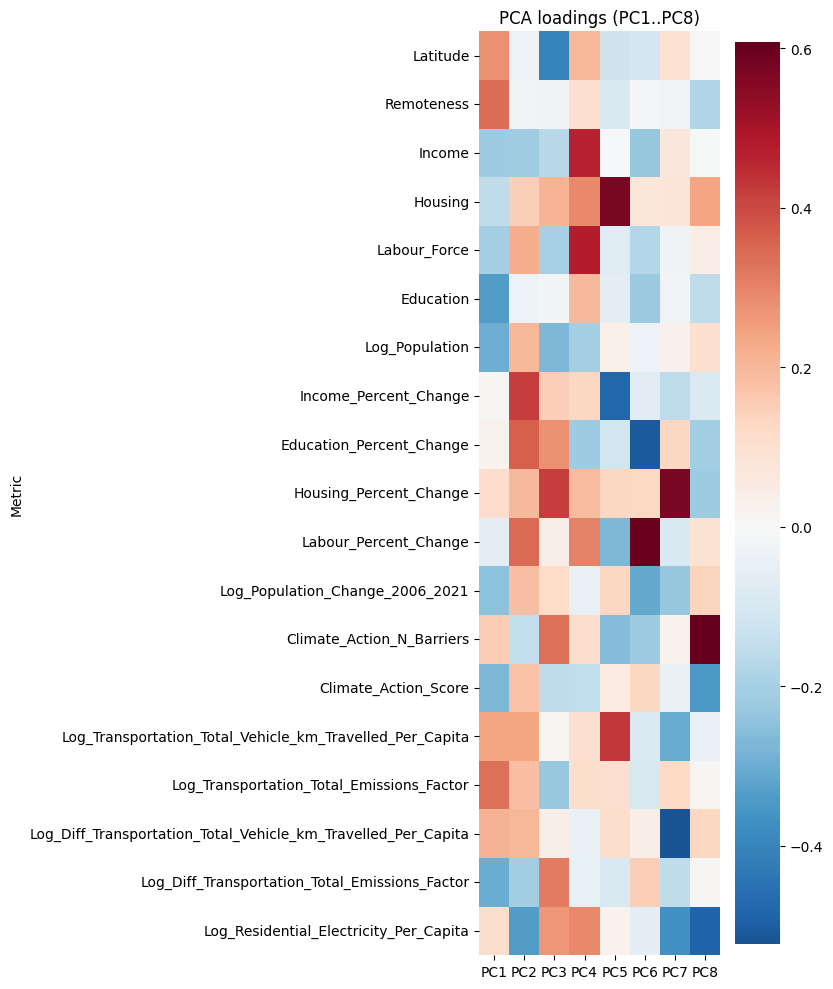

In [1063]:
# Heatmap of loadings for PC's giving 80% of variance
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,10))
sns.heatmap(loadings.iloc[:, :X_pca_80.shape[1]], cmap='RdBu_r', center=0, annot=False)
plt.title('PCA loadings (PC1..PC{})'.format(X_pca_80.shape[1]))
plt.tight_layout()
plt.show()


In [1087]:
# Quick summary per cluster
display(clustered.groupby('Cluster').mean().round(5))
#save means in a csv
clustered.groupby('Cluster').mean().round(5).to_csv(os.path.join('..','..','data','processed','municipality_clusters_feature_means.csv'))

#display standard deviation per cluster
display(clustered.groupby('Cluster').std().round(5))
clustered.groupby('Cluster').std().round(5).to_csv(os.path.join('..','..','data','processed','municipality_clusters_feature_std.csv'))

,Latitude,Remoteness,Income,Housing,Labour_Force,Education,Log_Population,Income_Percent_Change,Education_Percent_Change,Housing_Percent_Change,Labour_Percent_Change,Log_Population_Change_2006_2021,Climate_Action_N_Barriers,Climate_Action_Score,Log_Transportation_Total_Vehicle_km_Travelled_Per_Capita,Log_Transportation_Total_Emissions_Factor,Log_Diff_Transportation_Total_Vehicle_km_Travelled_Per_Capita,Log_Diff_Transportation_Total_Emissions_Factor,Log_Residential_Electricity_Per_Capita
Cluster,,,,,,,,,,,,,,,,,,,
1,52.25104,0.44452,78.29508,93.68852,83.01639,58.91803,3.28637,10.49566,11.67860,1.07660,-2.06233,-0.00121,4.24590,1.14754,4.10883,0.00017,0.07641,3.35811,1.34371
2,49.38941,0.21584,83.08140,95.73256,86.56977,69.67442,4.20118,10.76321,11.56089,0.12804,-0.78759,0.08673,3.74419,3.03488,3.97173,0.00015,-0.00811,3.41611,1.27300


,Latitude,Remoteness,Income,Housing,Labour_Force,Education,Log_Population,Income_Percent_Change,Education_Percent_Change,Housing_Percent_Change,Labour_Percent_Change,Log_Population_Change_2006_2021,Climate_Action_N_Barriers,Climate_Action_Score,Log_Transportation_Total_Vehicle_km_Travelled_Per_Capita,Log_Transportation_Total_Emissions_Factor,Log_Diff_Transportation_Total_Vehicle_km_Travelled_Per_Capita,Log_Diff_Transportation_Total_Emissions_Factor,Log_Residential_Electricity_Per_Capita
Cluster,,,,,,,,,,,,,,,,,,,
1,2.38662,0.10029,4.11641,2.57902,4.63498,4.82112,0.46251,4.78207,11.09496,3.74940,4.90888,0.05136,0.72240,1.10809,0.14046,0.00002,0.09173,0.03724,0.12165
2,0.75941,0.11259,5.29865,1.45055,2.41827,6.01457,0.65108,3.33807,4.73730,1.72683,2.39980,0.05956,0.88366,1.60476,0.14133,0.00001,0.09607,0.03071,0.12556


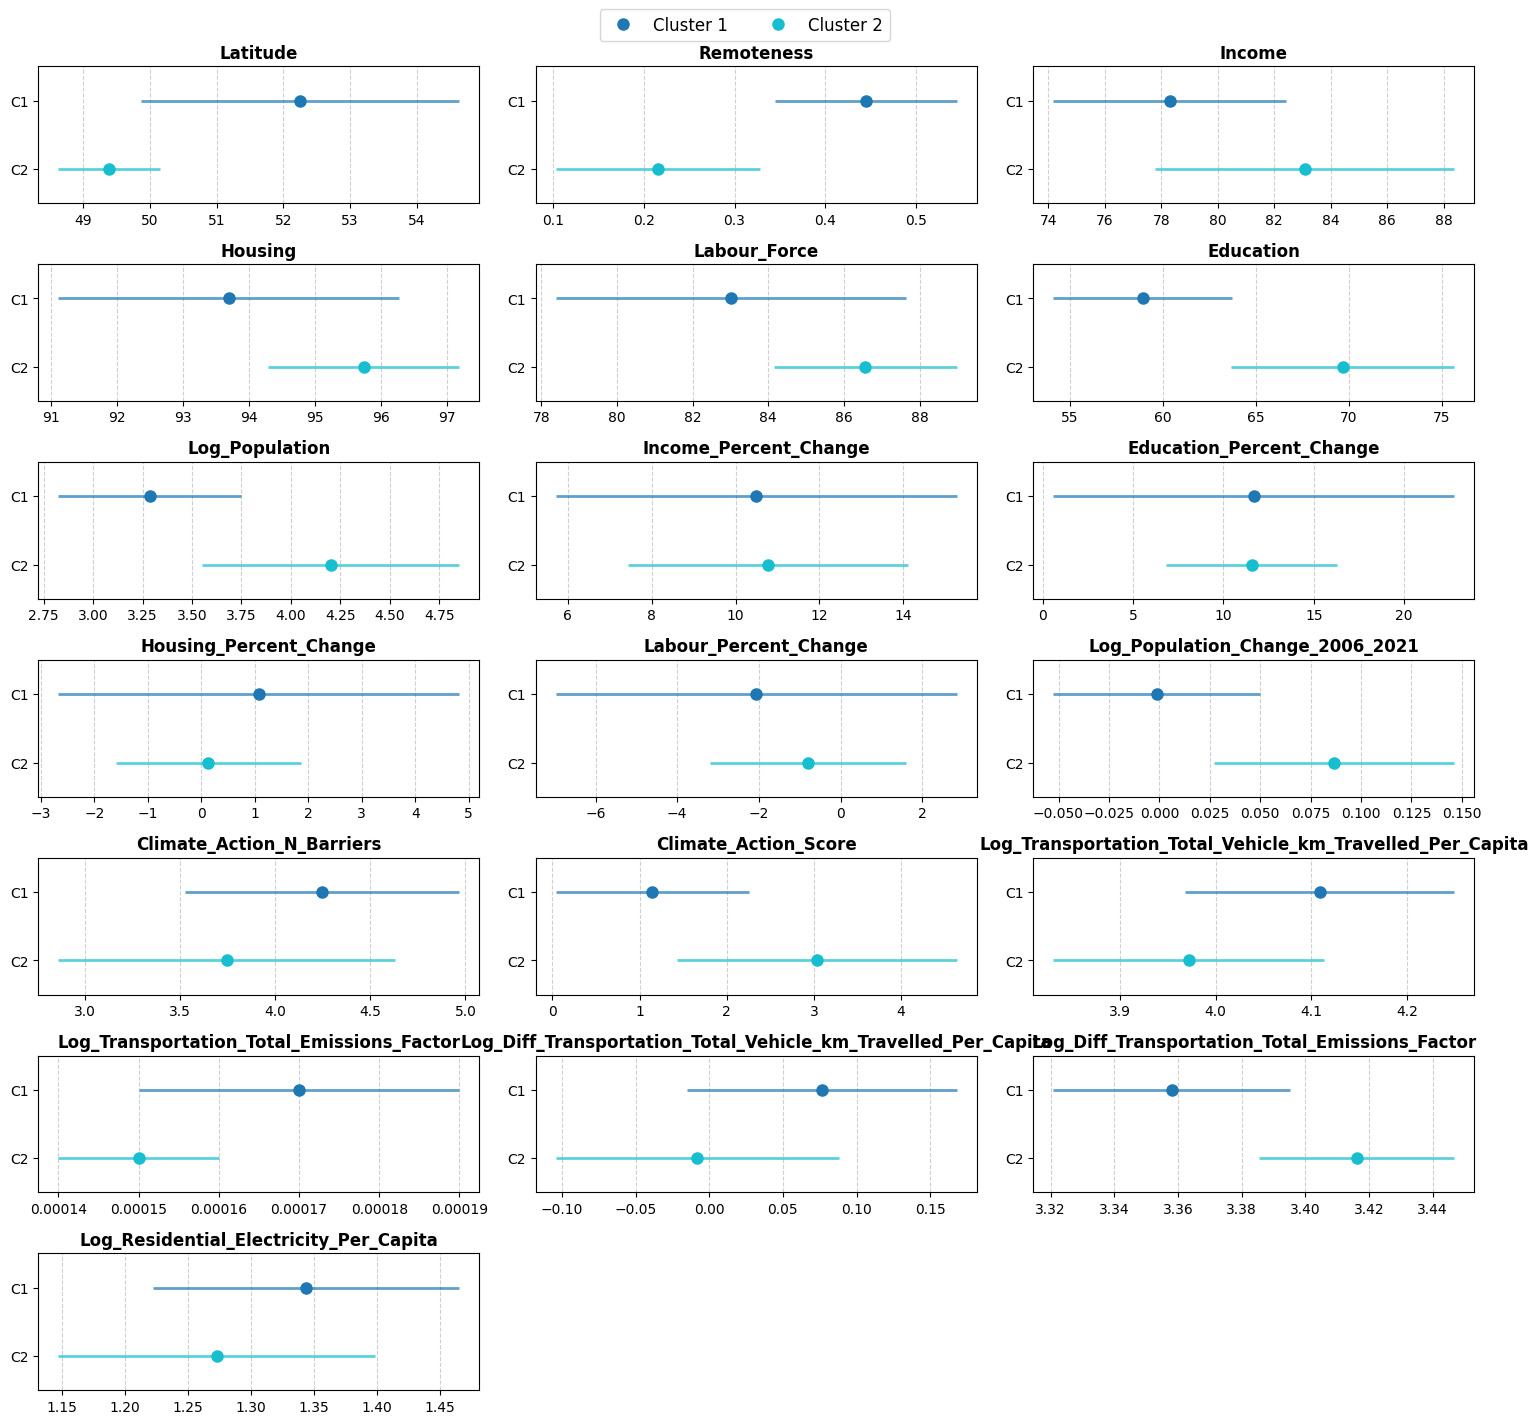

In [1110]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data
means_df = pd.read_csv(os.path.join('..','..','data','processed','municipality_clusters_feature_means.csv'))
stds_df = pd.read_csv(os.path.join('..','..','data','processed','municipality_clusters_feature_std.csv'))

# 2. Extract features and cluster labels
# We exclude the 'Cluster' column because it's our y-axis category, not a feature
features = [col for col in means_df.columns if col != 'Cluster']
n_features = len(features)
clusters = means_df['Cluster'].values

# 3. Calculate grid size for the subplots
cols = 3
# Automatically calculate how many rows are needed for 18 features (18/3 = 6 rows)
rows = int(np.ceil(n_features / cols))

# 4. Create the figure and axes
# figsize determines the width and height of the whole image. Adjust as needed!
fig, axes = plt.subplots(rows, cols, figsize=(15, 1*best_k*rows))
#fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Create a color map so each cluster has a distinct color
colors = plt.cm.tab10(np.linspace(0, 1, len(clusters)))

# 5. Loop through each feature and plot it
for i, feature in enumerate(features):
    ax = axes[i]
    
    # Extract the arrays of means and standard deviations for the current feature
    f_means = means_df[feature].values
    f_stds = stds_df[feature].values
    
    # Plot the dot and whisker for each cluster
    for j, cluster in enumerate(clusters):
        # Plot the horizontal whisker (mean - std to mean + std)
        ax.hlines(y=cluster, 
                  xmin=f_means[j] - f_stds[j], 
                  xmax=f_means[j] + f_stds[j], 
                  color=colors[j], linewidth=2, alpha=0.7)
                  
        # Plot the dot (the mean)
        ax.plot(f_means[j], cluster, 'o', color=colors[j], markersize=8, 
                label=f'Cluster {int(cluster)}' if i==0 else "")
        
    # Formatting for the specific subplot
    ax.set_title(feature, fontsize=12, fontweight='bold')
    ax.set_yticks(clusters)
    ax.set_yticklabels([f'C{int(c)}' for c in clusters])
    ax.set_ylim(min(clusters)-0.5, max(clusters)+0.5) # Add some padding around the clusters
    ax.invert_yaxis()  # Put Cluster 0 at the top, Cluster 2 at the bottom
    ax.grid(True, axis='x', linestyle='--', alpha=0.6) # Vertical grid lines for readability

# 6. Clean up empty subplots
# If your features aren't a perfect multiple of the columns, hide the extra blank plots
for k in range(n_features, len(axes)):
    fig.delaxes(axes[k])

# 7. Add a single master legend at the very top of the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=len(clusters), fontsize=12)

# 8. Adjust layout and save
plt.tight_layout()
plt.savefig('faceted_dot_whisker.png', bbox_inches='tight', dpi=300)
plt.show() # Uncomment this if you are running in a Jupyter Notebook to see it inline

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_1382/1477672590.py:4: UserWarning:

The palette list has more values (7) than needed (2), which may not be intended.



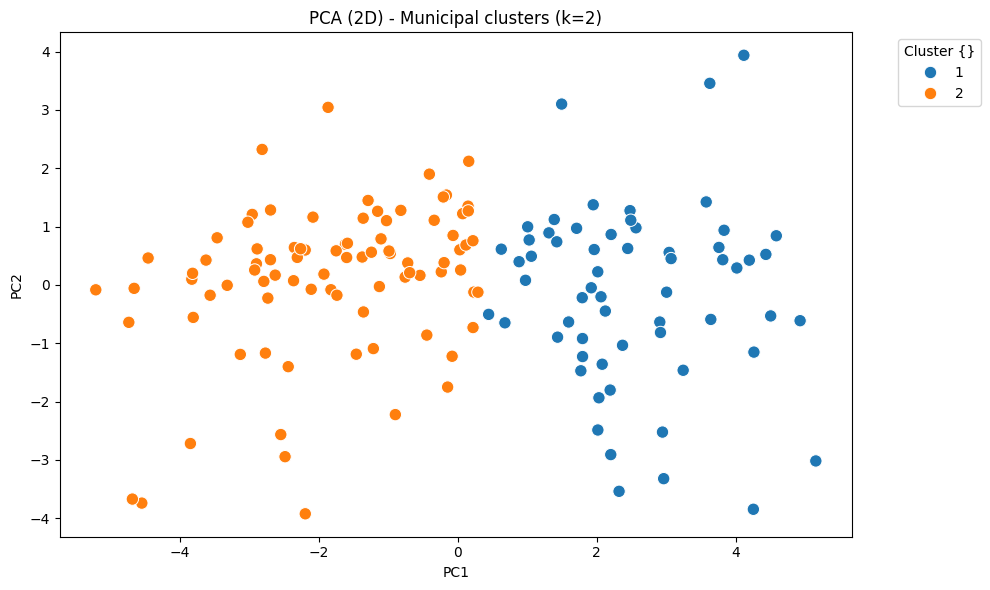

In [1089]:

# Plot PCA 2D scatter with cluster labels
plt.figure(figsize=(10,6))
palette = sns.color_palette('tab10', n_colors=manual_k)#best_k
sns.scatterplot(x=X_pca_80[:,0], y=X_pca_80[:,1], hue=labels_final, palette=palette, s=80, legend='full')
plt.title(f'PCA (2D) - Municipal clusters (k={best_k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster {}', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [1090]:
municipality_names = X.index


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_1382/2995698300.py:16: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



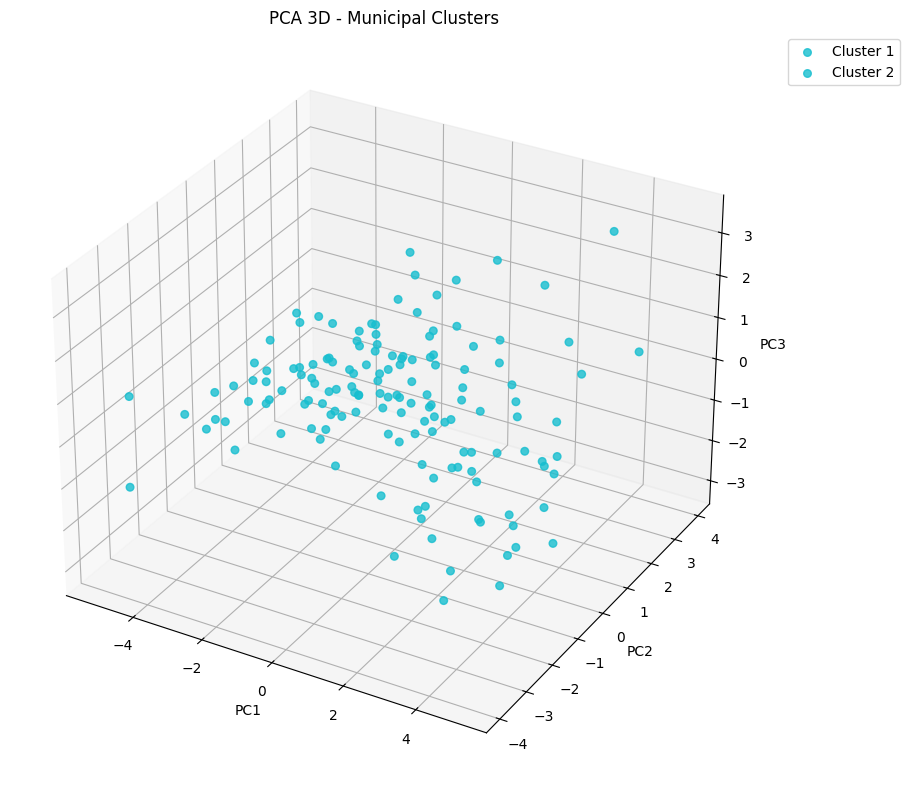

In [1091]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np
import pandas as pd


pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_for_clustering)
X_pca_3_standardized = StandardScaler().fit_transform(X_pca3)  # Equal weighting

df3 = pd.DataFrame(X_pca3, columns=['PC1','PC2','PC3'], index=municipality_names)
df3['Cluster'] = labels_final

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
palette = plt.cm.get_cmap('tab10', np.unique(labels_final).size)

for k in np.unique(labels_final):
    mask = df3['Cluster'] == k
    ax.scatter(
        df3.loc[mask, 'PC1'],
        df3.loc[mask, 'PC2'],
        df3.loc[mask, 'PC3'],
        label=f'Cluster {k}',
        s=30,
        alpha=0.8,
        color=palette(k)
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA 3D - Municipal Clusters')
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
#plt.savefig('reports/figures/pca_3d_clusters.png', dpi=200, bbox_inches='tight')
plt.show()


In [1092]:
import plotly.express as px
import pandas as pd


# X_pca3: numpy array shape (n_samples, 3)
# labels_final: 1D array of cluster labels
# municipality_names: index or list of municipality names (length n_samples)
municipality_names = X.index
df3 = pd.DataFrame(X_pca3, columns=['PC1','PC2','PC3'], index=municipality_names)
df3['Cluster'] = labels_final
df3['Municipality'] = df3.index

fig = px.scatter_3d(
    df3,
    x='PC1', y='PC2', z='PC3',
    color='Cluster',
    hover_name='Municipality',
    #symbol='Cluster',
    size_max=6,
    title='PCA 3D - Municipal Clusters',
    opacity=0.9
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(scene=dict(
    xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'
))
fig.show()

# Optional: save interactive HTML
#fig.write_html('reports/figures/pca_3d_clusters.html', include_plotlyjs='cdn')


In [1093]:
#calculate mean and std dev for all features of munis within each cluster, even the ones not used in clustering
# Pivot tidy_all_data to wide: municipalities × features
df_wide = tidy_all_data.pivot_table(
    index='Municipality_Name',
    columns='Metric',
    values='Value',
    aggfunc='first'  # in case of duplicates
)

# Add cluster labels (merge clusters_df into df_wide)
df_wide = df_wide.merge(clusters_df, left_index=True, right_index=True, how='left')

# Now compute stats per cluster
cluster_stats = df_wide.groupby('Cluster').agg(['mean', 'std'])
display(cluster_stats)

CSMI_Electricity_Level_Percent_Change            \
                                         mean       std   
Cluster                                                   
1                                   -0.030369  0.552620   
2                                    0.128251  0.486491   

        CSMI_Electricity_Share_Percent_Change            \
                                         mean       std   
Cluster                                                   
1                                    0.223035  0.970262   
2                                    0.313352  2.940063   

        CSMI_Polluting_Level_Percent_Change            \
                                       mean       std   
Cluster                                                 
1                                  0.045496  0.885608   
2                                  0.243791  0.685957   

        CSMI_Total_Energy_Share_Percent_Change                  CWB           \
                                          mean       std       mean      std   
Cluster                                                                        
1                                    -0.020808  0.265863  75.393443  3.25207   
2                                     0.008235  0.173870  80.174419  3.53534   

         ... Utility_Total_Energy                \
         ...                 mean           std   
Cluster  ...                                      
1        ...         6.554469e+05  1.087520e+06   
2        ...         3.634265e+06  6.852492e+06   

        Utility_Total_Polluting_Emissions                 \
                                     mean            std   
Cluster                                                    
1                            24081.462490   47947.520767   
2                           117416.377305  227383.357385   

        Utility_Total_Polluting_Energy                \
                                  mean           std   
Cluster                                                
1                         4.813391e+05  9.615878e+05   
2                         2.349618e+06  4.569990e+06   

        Utility_Total_Polluting_Energy_Share           Utility_WOOD_Emissions  \
                                        mean       std                   mean   
Cluster                                                                         
1                                   0.490816  0.253316            1161.969470   
2                                   0.553209  0.202915            3619.339512   

                      
                 std  
Cluster               
1        1932.202984  
2        5261.243445  

[2 rows x 278 columns]

In [1094]:
X

Metric,Latitude,Remoteness,Income,Housing,Labour_Force,Education,Log_Population,Income_Percent_Change,Education_Percent_Change,Housing_Percent_Change,Labour_Percent_Change,Log_Population_Change_2006_2021,Climate_Action_N_Barriers,Climate_Action_Score,Log_Transportation_Total_Vehicle_km_Travelled_Per_Capita,Log_Transportation_Total_Emissions_Factor,Log_Diff_Transportation_Total_Vehicle_km_Travelled_Per_Capita,Log_Diff_Transportation_Total_Emissions_Factor,Log_Residential_Electricity_Per_Capita
Municipality_Name,,,,,,,,,,,,,,,,,,,
Abbotsford,49.052222,0.137854,77.0,93.0,87.0,63.0,5.186176,10.000000,10.526316,-2.105263,-2.247191,0.093231,3.0,2.0,4.019773,0.000164,0.071227,3.372551,1.139457
Alert Bay,50.583889,0.532555,75.0,87.0,80.0,68.0,2.652246,5.633803,25.925926,-3.333333,-13.043478,-0.092828,4.0,1.0,3.823133,0.000140,0.143130,3.415681,1.486558
Anmore,49.314444,0.105959,94.0,96.0,85.0,77.0,3.372175,8.045977,6.944444,-1.030928,-8.602151,0.120537,4.0,0.0,3.890847,0.000134,-0.066367,3.442974,1.360243
Armstrong,50.448333,0.282934,78.0,97.0,88.0,62.0,3.726156,13.043478,14.814815,0.000000,2.325581,0.098688,4.0,0.0,4.045750,0.000163,-0.033148,3.366568,1.201166
Ashcroft,50.721389,0.404410,78.0,90.0,81.0,56.0,3.222716,8.333333,12.000000,-1.098901,0.000000,0.001563,4.0,2.0,4.059918,0.000170,0.042582,3.362708,1.242716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Warfield,49.094167,0.382688,82.0,93.0,87.0,70.0,3.243782,12.328767,9.375000,-4.123711,-1.136364,0.005987,5.0,1.0,4.003123,0.000144,0.052737,3.453320,1.131529
West Vancouver,49.331111,0.063003,100.0,95.0,81.0,83.0,4.644655,1.010101,5.063291,-1.041667,-5.813953,0.020053,3.0,5.0,3.808674,0.000127,-0.146418,3.473699,1.323525
Whistler,50.117222,0.199452,87.0,94.0,86.0,79.0,4.145569,7.407407,5.333333,-2.083333,-7.526882,0.179521,3.0,4.0,3.963971,0.000144,-0.077418,3.415571,1.729049


Features ranked by eta-squared (variance explained by clusters):


,eta_squared
Remoteness,0.526
Log_Transportation_Total_Emissions_Factor,0.517
Education,0.480
Latitude,0.428
Log_Diff_Transportation_Total_Emissions_Factor,0.424
Log_Population,0.379
Log_Population_Change_2006_2021,0.375
Climate_Action_Score,0.303
Housing,0.205
Labour_Force,0.201


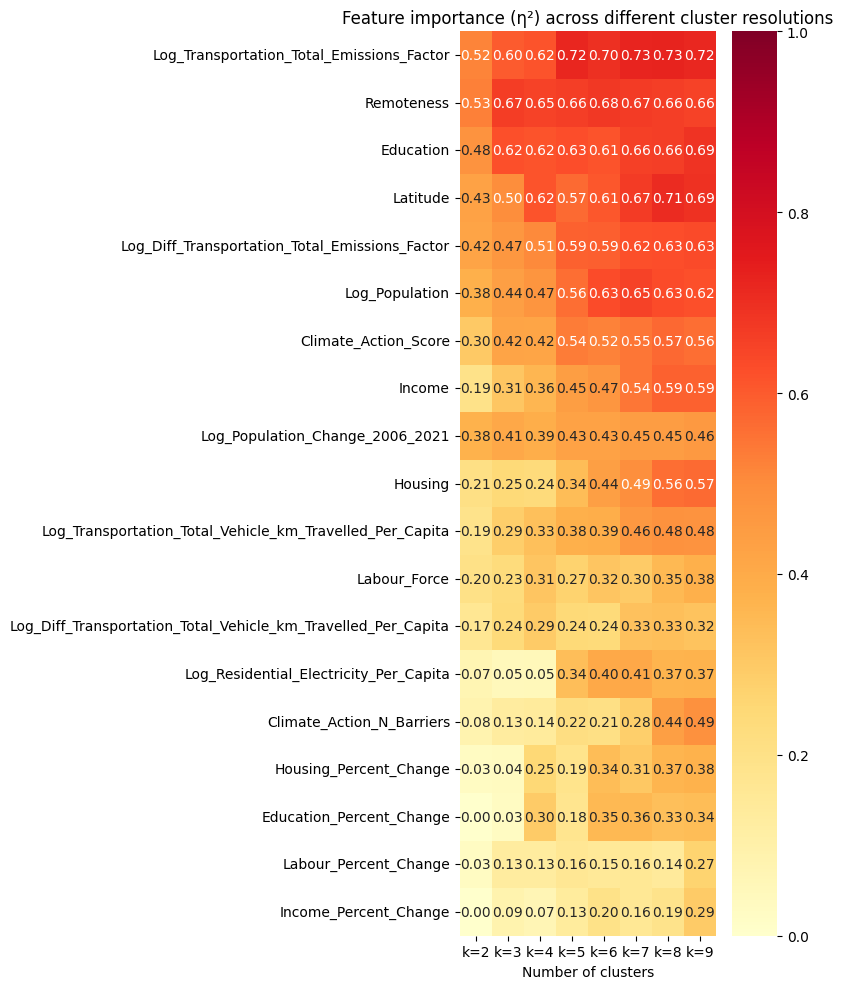


Top features by permutation importance (random forest predicting clusters):


Metric
Remoteness                                                       0.0073
Log_Transportation_Total_Emissions_Factor                        0.0063
Education                                                        0.0045
Latitude                                                         0.0000
Log_Population_Change_2006_2021                                  0.0000
Log_Diff_Transportation_Total_Emissions_Factor                   0.0000
Log_Diff_Transportation_Total_Vehicle_km_Travelled_Per_Capita    0.0000
Log_Transportation_Total_Vehicle_km_Travelled_Per_Capita         0.0000
Climate_Action_Score                                             0.0000
Climate_Action_N_Barriers                                        0.0000
dtype: float64

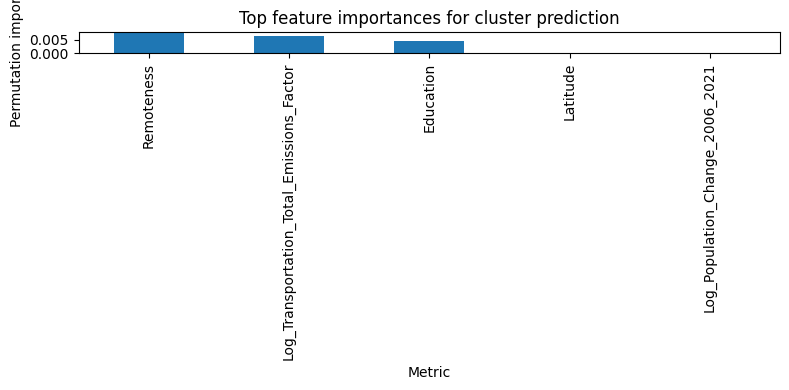


Interpretation hints:
- PCA loadings: large absolute loading = strong contributor to that PC.
- Explained variance: which PCs capture most variance.
- Cluster centroids: show how clusters differ on original features.
- ANOVA F: features with large F differ most across clusters (statistical).
- Permutation RF importance: features that best predict cluster membership (useful for interpretability).


In [1095]:
# Eta-squared for each feature across k clusters
def eta_squared(X, labels, col):
    groups = [X[col].values[labels == k] for k in np.unique(labels)] #gets the values from one feature (from cols), and splits it into groups based on the cluster labels
    grand_mean = X[col].mean()
    
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((X[col].values - grand_mean)**2)
    
    return ss_between / ss_total if ss_total > 0 else 0

effect_sizes = {}
for col in X.columns:
    effect_sizes[col] = eta_squared(X, labels_final, col)

eta_df = pd.DataFrame.from_dict(effect_sizes, orient='index', columns=['eta_squared']).sort_values('eta_squared', ascending=False)
print("Features ranked by eta-squared (variance explained by clusters):")
display(eta_df.round(3))

import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have a dict of labels for different k values
# e.g., all_labels = {2: labels_k2, 3: labels_k3, ..., 7: labels_k7}

eta_matrix = {}
for k, labels in all_labels.items():
    eta_matrix[f'k={k}'] = {col: eta_squared(X, labels, col) for col in X.columns}

eta_heatmap = pd.DataFrame(eta_matrix)

# Sort rows by mean eta-squared across all k
eta_heatmap = eta_heatmap.loc[eta_heatmap.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(8, 10))
sns.heatmap(eta_heatmap, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1)
plt.title('Feature importance (η²) across different cluster resolutions')
plt.xlabel('Number of clusters')
plt.tight_layout()
plt.show()

# Supervised check: how predictive each feature is of the cluster (permutation importance)
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
#X_filled = X.fillna(X.median())
#rf.fit(X_filled, labels_final)
rf.fit(X, labels_final)
perm = permutation_importance(rf, X, labels_final, n_repeats=30, random_state=42, n_jobs=-1)
#perm = permutation_importance(rf, X_filled, labels_final, n_repeats=30, random_state=42, n_jobs=-1)
imp_df = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print("\nTop features by permutation importance (random forest predicting clusters):")
display(imp_df.head(10).round(4))

plt.figure(figsize=(8,4))
imp_df.head(5).plot.bar()
plt.ylabel('Permutation importance')
plt.title('Top feature importances for cluster prediction')
plt.tight_layout()
plt.show()

# Guidance:
print("\nInterpretation hints:")
print("- PCA loadings: large absolute loading = strong contributor to that PC.")
print("- Explained variance: which PCs capture most variance.")
print("- Cluster centroids: show how clusters differ on original features.")
print("- ANOVA F: features with large F differ most across clusters (statistical).")
print("- Permutation RF importance: features that best predict cluster membership (useful for interpretability).")


In [1096]:
eta_df.to_csv(os.path.join('..','..','data','processed','feature_eta_squared.csv'))
#get the order of features by eta-squared
eta_order = eta_df.sort_values('eta_squared', ascending=False).index.tolist()
print("Features ranked by eta-squared (variance explained by clusters):")
for i, feat in enumerate(eta_order):
    print(f"{i+1}. {feat} (η²={eta_df.loc[feat,'eta_squared']:.3f})")

Features ranked by eta-squared (variance explained by clusters):
1. Remoteness (η²=0.526)
2. Log_Transportation_Total_Emissions_Factor (η²=0.517)
3. Education (η²=0.480)
4. Latitude (η²=0.428)
5. Log_Diff_Transportation_Total_Emissions_Factor (η²=0.424)
6. Log_Population (η²=0.379)
7. Log_Population_Change_2006_2021 (η²=0.375)
8. Climate_Action_Score (η²=0.303)
9. Housing (η²=0.205)
10. Labour_Force (η²=0.201)
11. Income (η²=0.194)
12. Log_Transportation_Total_Vehicle_km_Travelled_Per_Capita (η²=0.189)
13. Log_Diff_Transportation_Total_Vehicle_km_Travelled_Per_Capita (η²=0.165)
14. Climate_Action_N_Barriers (η²=0.084)
15. Log_Residential_Electricity_Per_Capita (η²=0.074)
16. Labour_Percent_Change (η²=0.029)
17. Housing_Percent_Change (η²=0.028)
18. Income_Percent_Change (η²=0.001)
19. Education_Percent_Change (η²=0.000)


In [1097]:
import numpy as np
import pandas as pd

# Assume X_pca_80 is your PCA matrix, labels_final are your cluster labels, and municipality_names is your index
centroids = kmeans_final.cluster_centers_
results = []

for k in np.unique(labels_final):
    # Indices for municipalities in cluster k
    idx = np.where(labels_final == k)[0]
    cluster_points = X_pca_80[idx]
    names = municipality_names[idx]

    # Distances to all centroids (including own)
    all_dists = np.linalg.norm(cluster_points[:, None, :] - centroids[None, :, :], axis=2)
    # For each point, find the minimum distance to any centroid (including own)
    min_dist_to_any_centroid = all_dists.min(axis=1)
    # The "most isolated" point is the one with the largest min distance to any centroid
    most_isolated_idx = np.argmax(min_dist_to_any_centroid)

    # Distances to own centroid
    own_dist = np.linalg.norm(cluster_points - centroids[k-1], axis=1)
    typical_idx = np.argmin(own_dist)

    results.append({
        'cluster': k,
        'typical_muni': names[typical_idx],
        'borderline_muni': names[np.argmin(all_dists[:, np.arange(len(centroids)) != (k-1)].min(axis=1))],
        'most_different_muni': names[most_isolated_idx]
    })

df_case_study_results = pd.DataFrame(results)
print(df_case_study_results)

   cluster typical_muni borderline_muni most_different_muni
0        1     Lillooet           Trail           Greenwood
1        2   Coldstream            Hope           Lions Bay


In [1098]:
# get population feature values for the communityies in the df_case_study_results
typical_muni_names = df_case_study_results["typical_muni"].tolist()
borderline_muni_names = df_case_study_results["borderline_muni"].tolist()
most_diff_muni_names = df_case_study_results["most_different_muni"].tolist()

In [1099]:
features_most_diff_muni_names = clustered[clustered.index.isin(most_diff_muni_names)]
features_most_diff_muni_names.to_csv(os.path.join('..','..','data','processed','most_different_municipalities_features.csv'))

In [1100]:
features_borderline_muni_names = clustered[clustered.index.isin(borderline_muni_names)]
features_borderline_muni_names.to_csv(os.path.join('..','..','data','processed','borderline_municipalities_features.csv'))

In [1101]:
features_typical_muni_names = clustered[clustered.index.isin(typical_muni_names)]
features_typical_muni_names.to_csv(os.path.join('..','..','data','processed','typical_municipalities_features.csv'))

In [1102]:
# Create tidy cluster dataframe, attach lat/lon, save and plot on BC map
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

BASE_YEAR = 2021
metric_name = 'cluster_energy_wellbeing'   # change to 'cluster_energy' or other if desired
unit_name = 'cluster_number'

# 1) Build clusters DataFrame (expecting either clusters_df or labels_final + X.index)
if 'clusters_df' in globals():
    clusters_src = clusters_df.reset_index()[['Municipality_Name', 'Cluster']].copy()
else:
    # fall back to labels_final and X.index
    if 'labels_final' in globals() and 'X' in globals():
        clusters_src = pd.DataFrame({
            'Municipality_Name': X.index,
            'Cluster': labels_final
        })
    else:
        raise RuntimeError("No cluster results found. Run the clustering cells first (need `clusters_df` or `labels_final` + `X`).")

clusters_src.head()

,Municipality_Name,Cluster
0,Abbotsford,2
1,Alert Bay,1
2,Anmore,2
3,Armstrong,2
4,Ashcroft,1


In [1103]:
#merge cluster numbers with df_wide by matching municiopality names
df_wide = tidy_all_data.pivot_table(
    index='Municipality_Name',
    columns='Metric',
    values='Value',
)

# Add cluster labels (merge clusters_df into df_wide)
df_wide = df_wide.merge(clusters_df, left_index=True, right_index=True, how='left')


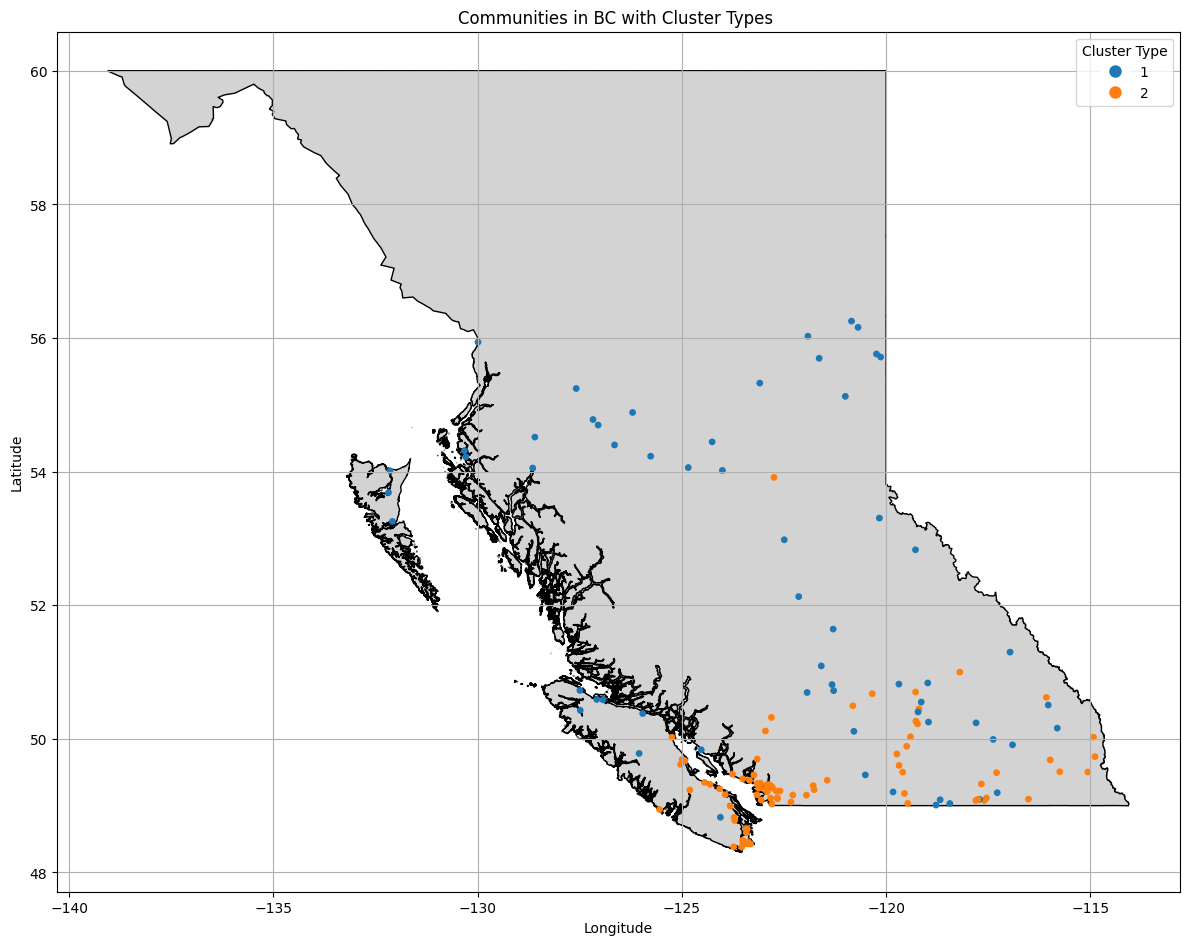

In [1104]:
#plot the final analysis data with coordinates on a map of BC, with shapefile located in the raw dataset subfolder BC_Boundary as BC_Boundary.shp
import geopandas as gpd
# Load the shapefile for BC boundaries
bc_boundaries = gpd.read_file(os.path.join('..','..', 'data', 'raw', 'BC_Boundary', 'BC_Boundary.shp'))
# Convert the final analysis data with coordinates to a GeoDataFrame
final_analysis_gdf = gpd.GeoDataFrame(
    df_wide,
    geometry=gpd.points_from_xy(df_wide['Longitude'], df_wide['Latitude']),
    crs='EPSG:4326'  # WGS84 coordinate system
)
"""
cluster_colors = {
    0: 'green',
    1: 'blue',
    2: 'orange',
    3: 'purple',
    4: 'pink',
    5: 'red',
    6: 'black'  
}
"""
# Plot BC base map and clusters (one color per cluster)
clusters = sorted([c for c in df_wide['Cluster'].dropna().unique()])
n_clusters = max(1, len(clusters))
palette = sns.color_palette('tab10', n_colors=max(10, n_clusters))
cluster_colors = {c: palette[i % len(palette)] for i, c in enumerate(clusters)}

final_analysis_gdf['color'] = final_analysis_gdf['Cluster'].map(cluster_colors)

plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
#plot the map with legend showing each color based on decoupling type
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color=final_analysis_gdf['color'], markersize=15, label='Communities')
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in cluster_colors.items()]
plt.legend(handles=handles, title='Cluster Type', loc='upper right')

plt.title('Communities in BC with Cluster Types ')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()

In [1105]:
BASE_YEAR = 2021
metric_name = 'cluster_energy_wellbeing'   # change to 'cluster_energy' or other if desired
unit_name = 'cluster_number'
# 2) Save tidy cluster table with Year, Metric, Value, Unit
tiny_cluster = clusters_src.copy()
tiny_cluster['Year'] = BASE_YEAR
tiny_cluster['Metric'] = metric_name
tiny_cluster['Value'] = tiny_cluster['Cluster']   # cluster number as value
tiny_cluster['Unit'] = unit_name
tiny_cluster = tiny_cluster[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']]

# 5) Save tidy cluster CSV
out_path = os.path.join('..', '..', 'data', 'processed', f'municipality_clusters_tidy_{metric_name}_{BASE_YEAR}.csv')
tiny_cluster.to_csv(out_path, index=False)
print(f"Saved tidy cluster CSV to: {out_path}")
print("Sample rows:")
display(tiny_cluster.head(10))


Saved tidy cluster CSV to: ../../data/processed/municipality_clusters_tidy_cluster_energy_wellbeing_2021.csv
Sample rows:


,Municipality_Name,Year,Metric,Value,Unit
0,Abbotsford,2021,cluster_energy_wellbeing,2,cluster_number
1,Alert Bay,2021,cluster_energy_wellbeing,1,cluster_number
2,Anmore,2021,cluster_energy_wellbeing,2,cluster_number
3,Armstrong,2021,cluster_energy_wellbeing,2,cluster_number
4,Ashcroft,2021,cluster_energy_wellbeing,1,cluster_number
5,Belcarra,2021,cluster_energy_wellbeing,2,cluster_number
6,Bowen Island,2021,cluster_energy_wellbeing,2,cluster_number
7,Burnaby,2021,cluster_energy_wellbeing,2,cluster_number
8,Burns Lake,2021,cluster_energy_wellbeing,1,cluster_number
9,Cache Creek,2021,cluster_energy_wellbeing,1,cluster_number


In [1106]:
#df_wide['Cluster']
tidy_cluster = df_wide.reset_index()[['Municipality_Name']].copy()
tidy_cluster['Year'] = BASE_YEAR
tidy_cluster['Metric'] = "Cluster"
tidy_cluster['Value'] = df_wide.reset_index()[['Cluster']].copy()
tidy_cluster['Unit'] = "cluster_number"
#append tidy_cluster to tidy_all_data
tidy_all_data_with_clusters = pd.concat([tidy_all_data, tidy_cluster], ignore_index=True)
tidy_all_data_with_clusters.tail()
#save tidy_all_data_with_clusters to csv
tidy_all_data_with_clusters.to_csv(os.path.join('..','..','data','processed','tidy_all_data_with_clusters.csv'), index=False)

In [1107]:
# Get municipalities with Latitude > 53.8 and their cluster numbers
high_lat = tidy_all_data_with_clusters[
    (tidy_all_data_with_clusters['Year'] == 2021) &
    (tidy_all_data_with_clusters['Metric'] == 'Latitude') &
    (tidy_all_data_with_clusters['Value'] > 53.6)
]['Municipality_Name']

clusters = tidy_all_data_with_clusters[
    (tidy_all_data_with_clusters['Year'] == 2021) &
    (tidy_all_data_with_clusters['Metric'] == 'Cluster') &
    (tidy_all_data_with_clusters['Municipality_Name'].isin(high_lat))
][['Municipality_Name', 'Value']]

print(clusters)

       Municipality_Name  Value
128092        Burns Lake    1.0
128099          Chetwynd    1.0
128110      Dawson Creek    1.0
128117    Fort St. James    1.0
128118     Fort St. John    1.0
128119       Fraser Lake    1.0
128125          Granisle    1.0
128130           Houston    1.0
128131     Hudson's Hope    1.0
128139           Kitimat    1.0
128151         Mackenzie    1.0
128153            Masset    1.0
128164      New Hazelton    1.0
128181     Port Clements    1.0
128183       Port Edward    1.0
128187       Pouce Coupe    1.0
128189     Prince George    2.0
128190     Prince Rupert    1.0
128206          Smithers    1.0
128211           Stewart    1.0
128214            Taylor    1.0
128215            Telkwa    1.0
128216           Terrace    1.0
128218     Tumbler Ridge    1.0
128222        Vanderhoof    1.0


In [1108]:
tidy_all_data_with_clusters[
    (tidy_all_data_with_clusters['Municipality_Name']=='Smithers') &
    (tidy_all_data_with_clusters['Year'] == 2021) &
    (tidy_all_data_with_clusters['Metric'].isin(['Education', 'Remoteness','Log_Population','Log_Population_Change_2006_2021','Climate_Action_Score']))
    ]

,Municipality_Name,Year,Metric,Value,Unit
100611,Smithers,2021,Log_Population,3.730621,log10_count
100745,Smithers,2021,Log_Population_Change_2006_2021,0.013200,log10_count
115311,Smithers,2021,Education,67.000000,index
118076,Smithers,2021,Remoteness,0.475338,index
124531,Smithers,2021,Climate_Action_Score,5.000000,count out of 5


In [1109]:
tidy_all_data_with_clusters[
    (tidy_all_data_with_clusters['Municipality_Name']=='Prince George') &
    (tidy_all_data_with_clusters['Year'] == 2021) &
    (tidy_all_data_with_clusters['Metric'].isin(['Education', 'Remoteness','Log_Population','Log_Population_Change_2006_2021','Climate_Action_Score']))
    ]

,Municipality_Name,Year,Metric,Value,Unit
100614,Prince George,2021,Log_Population,4.884841,log10_count
100728,Prince George,2021,Log_Population_Change_2006_2021,0.033699,log10_count
115314,Prince George,2021,Education,64.000000,index
118079,Prince George,2021,Remoteness,0.317265,index
124515,Prince George,2021,Climate_Action_Score,3.000000,count out of 5
